In [ ]:
import google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Transcriptformer

In [ ]:
!pip install transcriptformer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.3/478.3 kB 27.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compat

## Torch

In [ ]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [ ]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
--index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 145.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.0 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

import torchvision.ops
print("OK ✔")

2.5.1+cu124
0.20.1+cu124
OK ✔


# Imports

In [ ]:
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
import mygene
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

model_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/tf_exemplar"
data_dir = "/content/drive/MyDrive/gp/data"

# Imports for classification models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [ ]:
def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

# PBMCs annotation

## Prepare the dataset

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/annotation/pbmcs

In [ ]:
pbmcs_data_path = os.path.join(data_dir, "GP_datasets/PBMCs/1k_pbmcs_proc_subset.h5ad")
adata = sc.read_h5ad(pbmcs_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 1000 × 12000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_types', 'hvg'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

In [ ]:
adata.var.index

Index(['SAMD11', 'PLEKHN1', 'HES4', 'ISG15', 'AGRN', 'C1orf159', 'TTLL10',
       'TNFRSF18', 'TNFRSF4', 'SDF4',
       ...
       'S100B', 'PRMT2', 'MT-ND1', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6',
       'MT-CO3', 'MT-ND4', 'MT-ND6'],
      dtype='object', length=12000)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")


INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped: 11818 / 12000


In [ ]:
adata

AnnData object with n_obs × n_vars = 1000 × 12000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'ensembl_id'
    uns: 'cell_types', 'hvg'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

In [ ]:
adata.obs['assay'] = '10x Genomics'


In [ ]:
adata

AnnData object with n_obs × n_vars = 1000 × 12000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type', 'assay'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'ensembl_id'
    uns: 'cell_types', 'hvg'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

In [ ]:
adata.write(os.path.join(data_dir, "pbmcs/pbmcs_ann.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(data_dir, "pbmcs/pbmcs_ann.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/annotation/pbmcs"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_pbmcs_ann_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-05-01 22:48:17,531 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-05-01 22:48:18,342 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-05-01 22:48:56,504 -

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,'transcriptformer_pbmcs_ann_embeddings.h5ad'))

In [ ]:
adata

AnnData object with n_obs × n_vars = 1000 × 0
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[-0.0366711 ,  0.28205428, -0.00611525, ...,  0.01846259,
         0.10843383,  0.04318167],
       [-0.02348881,  0.37919256, -0.00831605, ...,  0.0221372 ,
         0.2758203 ,  0.03324293],
       [-0.03293227,  0.10401394,  0.02571697, ...,  0.12973887,
         0.09811409,  0.04111711],
       ...,
       [ 0.0073419 ,  0.120223  ,  0.02805404, ...,  0.20508331,
         0.2005093 ,  0.14338225],
       [-0.10244526,  0.06678476,  0.10672234, ...,  0.1032044 ,
         0.09358139,  0.01972643],
       [-0.02391515,  0.01047662, -0.07434518, ...,  0.13431893,
         0.08598989,  0.05894906]], shape=(1000, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,'transcriptformer_pbmcs_ann_embeddings.h5ad'))

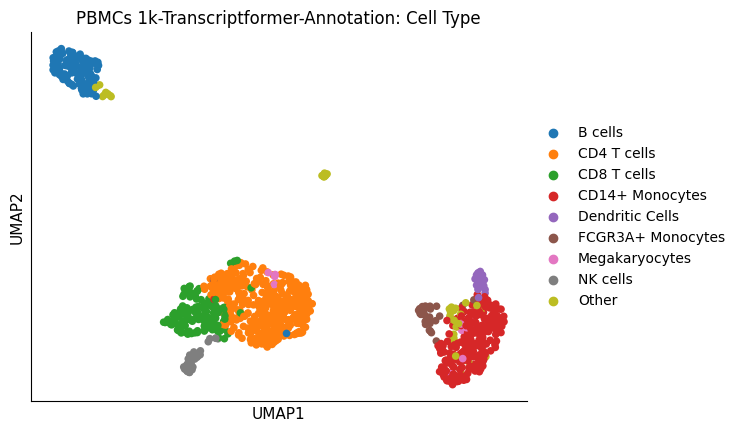

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "PBMCs 1k-Transcriptformer-Annotation: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Annotation

In [ ]:
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_transcriptformer"]
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


=== Logistic Regression ===
Accuracy: 0.976
                   precision    recall  f1-score   support

          B cells       1.00      0.99      1.00       127
  CD14+ Monocytes       0.97      0.99      0.98       222
      CD4 T cells       0.98      0.99      0.98       383
      CD8 T cells       0.97      0.95      0.96       126
  Dendritic Cells       0.95      0.95      0.95        22
FCGR3A+ Monocytes       1.00      0.81      0.89        31
   Megakaryocytes       1.00      0.70      0.82        10
         NK cells       0.95      0.97      0.96        36
            Other       0.95      0.98      0.97        43

         accuracy                           0.98      1000
        macro avg       0.97      0.93      0.95      1000
     weighted avg       0.98      0.98      0.98      1000



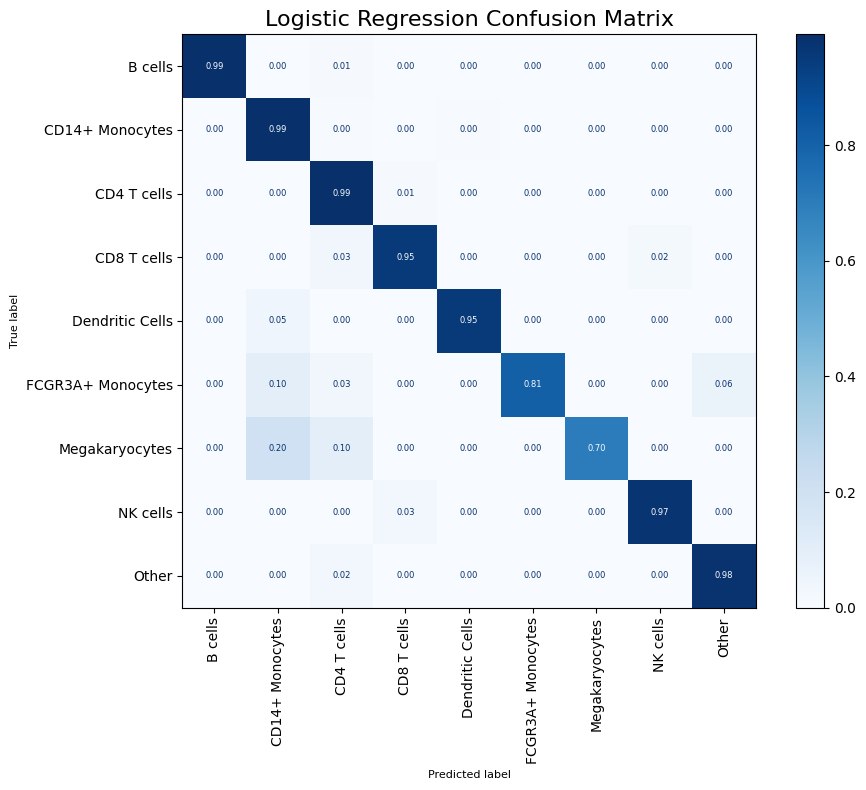


=== k-NN ===
Accuracy: 0.957
                   precision    recall  f1-score   support

          B cells       0.95      0.99      0.97       127
  CD14+ Monocytes       0.93      1.00      0.96       222
      CD4 T cells       0.97      0.99      0.98       383
      CD8 T cells       0.95      0.94      0.94       126
  Dendritic Cells       1.00      0.95      0.98        22
FCGR3A+ Monocytes       1.00      0.81      0.89        31
   Megakaryocytes       1.00      0.70      0.82        10
         NK cells       0.97      0.97      0.97        36
            Other       0.96      0.60      0.74        43

         accuracy                           0.96      1000
        macro avg       0.97      0.88      0.92      1000
     weighted avg       0.96      0.96      0.95      1000



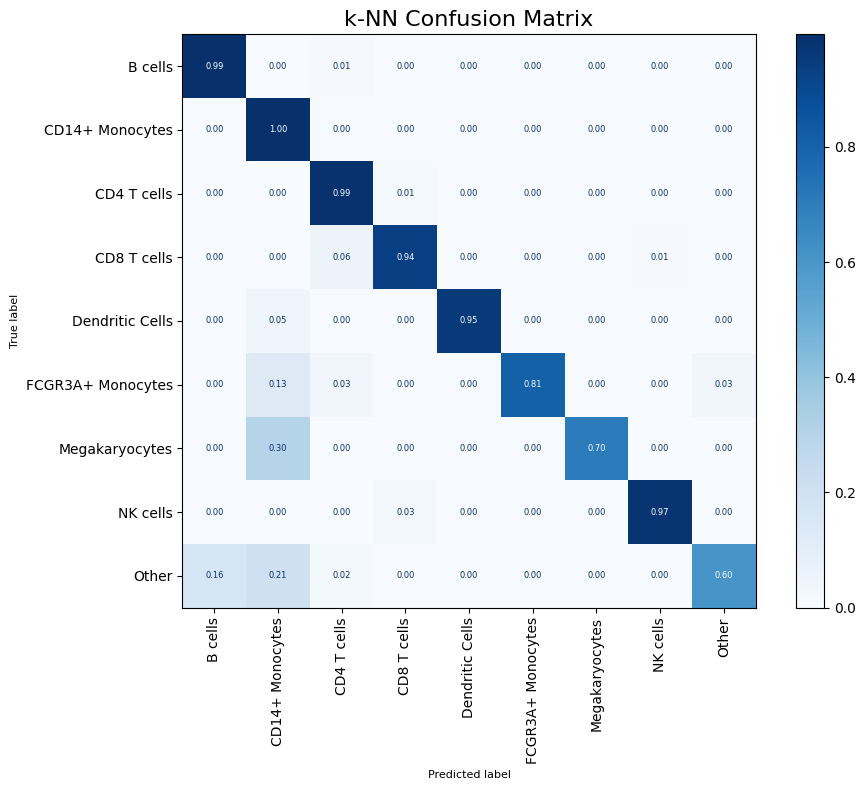

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

# HBECs annotation

## Prepare the dataset

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/annotation/hbces

In [ ]:
hbecs_data_path = os.path.join(data_dir, "GP_datasets/HBECs/HBECs.h5ad")
adata = sc.read_h5ad(hbecs_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 17451 × 22100
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio'

In [ ]:
adata.var.index

Index(['AL627309.1', 'AP006222.2', 'RP4-669L17.10', 'RP11-206L10.3',
       'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115', 'FAM41C', 'NOC2L',
       'KLHL17',
       ...
       'RP11-737O24.5', 'RP1-155G6.4', 'CTD-3032J10.3', 'CTB-176F20.3',
       'AC007193.8', 'AC008753.4', 'XXbac-B476C20.17', 'AF127936.3',
       'AP000695.6', 'AC109135.1'],
      dtype='object', length=22100)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")


INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

Mapped: 15743 / 22100


In [ ]:
adata

AnnData object with n_obs × n_vars = 17451 × 22100
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio'
    var: 'ensembl_id'

In [ ]:
adata.obs['assay'] = '10x Genomics'


In [ ]:
adata

AnnData object with n_obs × n_vars = 17451 × 22100
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.write(os.path.join(data_dir, "hbecs/hbecs_ann.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(data_dir, "hbecs/hbecs_ann.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/annotation/hbecs"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_hbecs_ann_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-05-01 22:53:54,093 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-05-01 22:53:54,094 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-05-01 22:54:13,720 -

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,'transcriptformer_hbecs_ann_embeddings.h5ad'))

In [ ]:
adata

AnnData object with n_obs × n_vars = 17451 × 0
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.08784033,  0.29095003, -0.2896041 , ..., -0.5242818 ,
         0.41286677, -0.15768427],
       [ 0.10276735,  0.6717686 , -0.01164804, ..., -0.29318368,
         0.08744302,  0.293512  ],
       [ 0.17596681,  0.20300575, -0.39093694, ..., -0.3132632 ,
         0.3004374 ,  0.1833164 ],
       ...,
       [ 0.23448656,  0.3761404 ,  0.2458229 , ..., -0.1099029 ,
        -0.03929438,  0.01058372],
       [ 0.19019958, -0.00778649, -0.2668141 , ..., -0.14088367,
        -0.01569023,  0.14292105],
       [ 0.00549404,  0.249255  , -0.28235543, ..., -0.1398985 ,
         0.04538044,  0.04571453]], shape=(17451, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,'transcriptformer_hbecs_ann_embeddings.h5ad'))

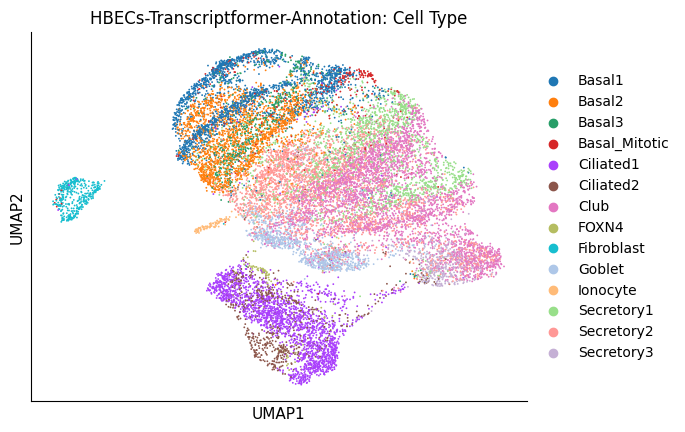

In [ ]:
ax = sc.pl.umap(
    adata,
    color='Cell type',
    frameon=True,
    title=[
        "HBECs-Transcriptformer-Annotation: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Annotation

In [ ]:
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_transcriptformer"]
y = adata.obs["Cell type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


=== Logistic Regression ===
Accuracy: 0.8569709472236549
               precision    recall  f1-score   support

       Basal1       0.88      0.91      0.90      1923
       Basal2       0.87      0.88      0.87      1922
       Basal3       0.76      0.69      0.72       556
Basal_Mitotic       0.90      0.83      0.86       305
    Ciliated1       0.94      0.95      0.95      2150
    Ciliated2       0.87      0.81      0.84       614
         Club       0.85      0.87      0.86      3347
        FOXN4       0.86      0.84      0.85        80
   Fibroblast       0.97      0.99      0.98       377
       Goblet       0.81      0.85      0.83       980
     Ionocyte       0.96      0.96      0.96       124
   Secretory1       0.80      0.80      0.80      1728
   Secretory2       0.83      0.81      0.82      2871
   Secretory3       0.75      0.73      0.74       474

     accuracy                           0.86     17451
    macro avg       0.86      0.85      0.86     17451
 weigh

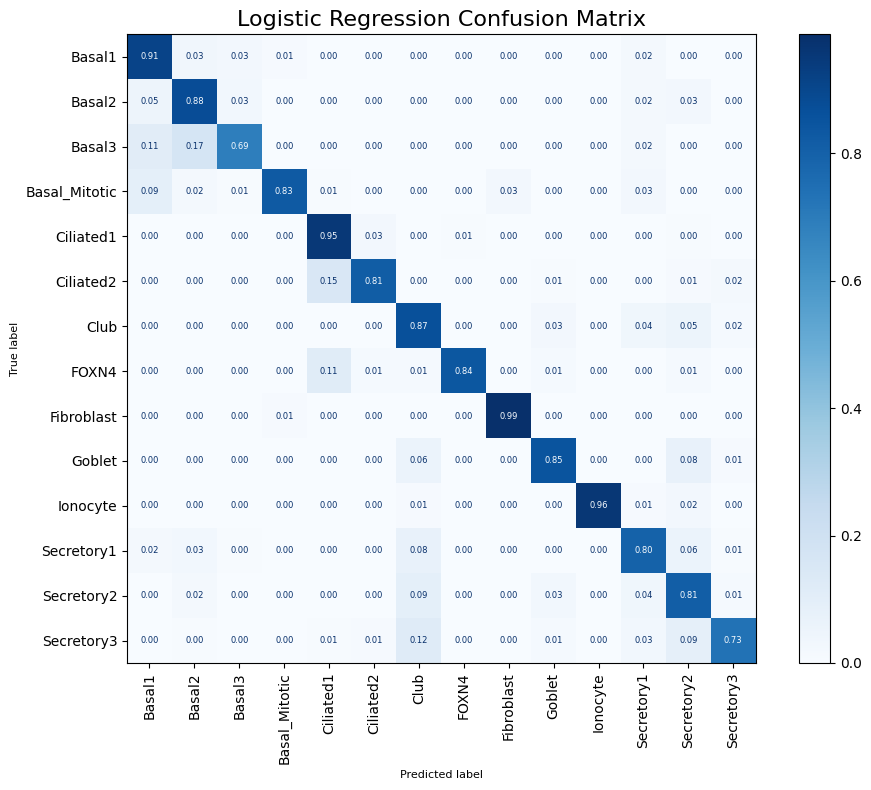


=== k-NN ===
Accuracy: 0.8191507649991404
               precision    recall  f1-score   support

       Basal1       0.81      0.94      0.87      1923
       Basal2       0.83      0.86      0.85      1922
       Basal3       0.82      0.47      0.60       556
Basal_Mitotic       0.97      0.46      0.62       305
    Ciliated1       0.91      0.97      0.94      2150
    Ciliated2       0.92      0.68      0.79       614
         Club       0.76      0.89      0.82      3347
        FOXN4       0.97      0.71      0.82        80
   Fibroblast       0.97      0.99      0.98       377
       Goblet       0.78      0.86      0.82       980
     Ionocyte       0.97      0.83      0.90       124
   Secretory1       0.77      0.73      0.75      1728
   Secretory2       0.82      0.71      0.76      2871
   Secretory3       0.73      0.60      0.66       474

     accuracy                           0.82     17451
    macro avg       0.86      0.76      0.80     17451
 weighted avg       

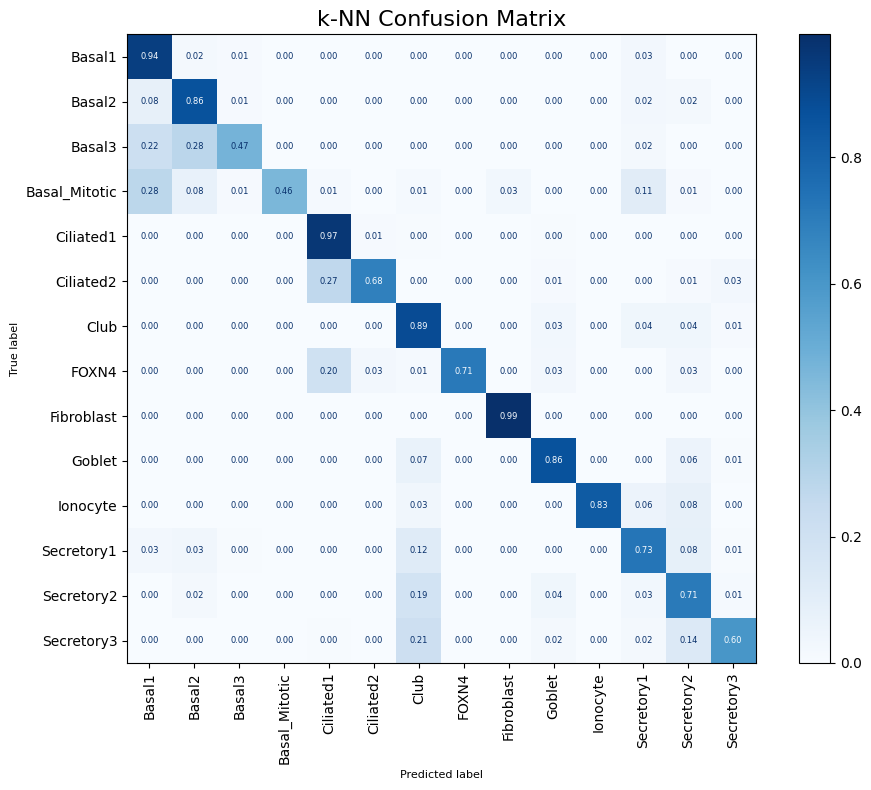

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

# Baron Pancreas Human annotation

## Prepare the dataset

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/annotation/pancreas

In [ ]:
pancreas_data_path = os.path.join(data_dir, "GP_datasets/Pancreas/Baron_Pancreas_Human_mix.h5ad")
adata = sc.read_h5ad(pancreas_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'

In [ ]:
adata.var.index

Index(['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AA06', 'AAAS',
       'AACS', 'AACSP1',
       ...
       'SPRYD4', 'SPRYD7', 'SPSB1', 'SPSB2', 'SPSB3', 'SPSB4', 'SPTA1',
       'SPTAN1', 'SPTB', 'SPTBN1'],
      dtype='object', length=16381)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-16381 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped: 15204 / 16381


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'
    var: 'ensembl_id'

In [ ]:
adata.obs['assay'] = 'inDrop'


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.write(os.path.join(data_dir, "pancreas/human_ann.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(data_dir, "pancreas/human_ann.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/annotation/pancreas/mouse"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_pancreas_ann_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-05-01 23:14:59,740 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-05-01 23:14:59,742 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-05-01 23:15:19,378 -

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,'transcriptformer_pancreas_ann_embeddings.h5ad'))

In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[-3.1270680e-01, -3.6588123e-01, -4.0516701e-01, ...,
        -9.4077915e-01,  3.2609800e-01,  2.0894404e-01],
       [-1.9460285e-01, -2.0131657e-01, -3.9958081e-01, ...,
        -1.1650203e+00,  2.2753341e-01,  3.0320024e-01],
       [-2.5111043e-01, -2.2353028e-01, -2.7945378e-01, ...,
        -6.8134433e-01,  3.1225705e-01,  1.9472556e-01],
       ...,
       [-4.1574381e-02,  4.5571949e-02,  1.3803245e-01, ...,
        -4.0411922e-01, -1.6866868e-02,  5.3874496e-02],
       [-1.8350897e-02,  1.1335901e-01,  1.2974505e-01, ...,
        -4.5432109e-01,  7.0883869e-04,  7.4873410e-02],
       [-1.7138025e-01, -1.4731886e-02, -1.2633480e-01, ...,
        -4.2012781e-01,  1.2344687e-01,  1.2684578e-01]],
      shape=(8569, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,'transcriptformer_pancreas_ann_embeddings.h5ad'))

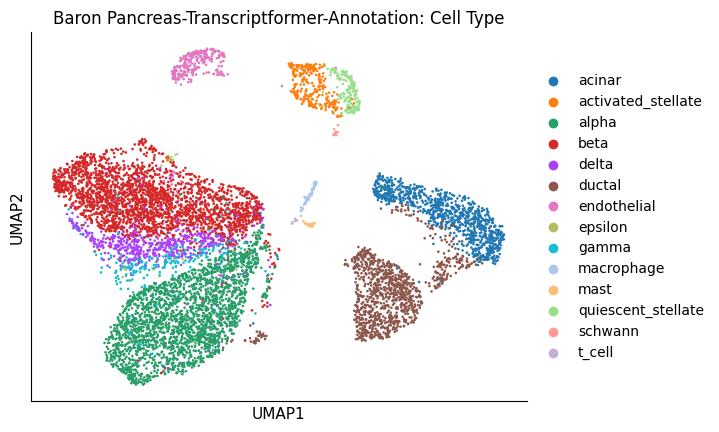

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Baron Pancreas-Transcriptformer-Annotation: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Annotation

In [ ]:
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_transcriptformer"]
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


=== Logistic Regression ===
Accuracy: 0.9787606488505076
                    precision    recall  f1-score   support

            acinar       0.98      0.99      0.98       958
activated_stellate       0.97      0.96      0.96       284
             alpha       0.99      1.00      0.99      2326
              beta       0.98      0.99      0.99      2525
             delta       0.94      0.95      0.94       601
            ductal       0.99      0.98      0.98      1077
       endothelial       1.00      0.99      0.99       252
           epsilon       0.89      0.44      0.59        18
             gamma       0.92      0.86      0.89       255
        macrophage       1.00      0.98      0.99        55
              mast       1.00      1.00      1.00        25
quiescent_stellate       0.93      0.94      0.94       173
           schwann       1.00      1.00      1.00        13
            t_cell       0.75      0.86      0.80         7

          accuracy                       

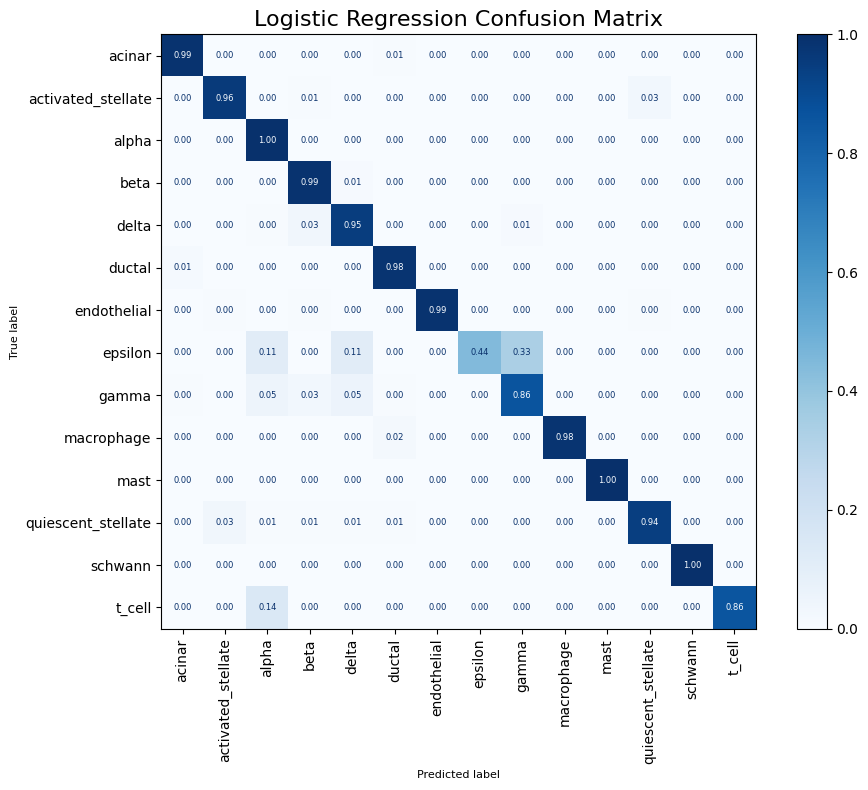


=== k-NN ===
Accuracy: 0.963122884817365
                    precision    recall  f1-score   support

            acinar       0.98      0.99      0.98       958
activated_stellate       0.97      0.96      0.97       284
             alpha       0.97      1.00      0.98      2326
              beta       0.97      0.99      0.98      2525
             delta       0.88      0.84      0.86       601
            ductal       0.99      0.97      0.98      1077
       endothelial       1.00      0.99      1.00       252
           epsilon       1.00      0.06      0.11        18
             gamma       0.85      0.63      0.73       255
        macrophage       1.00      1.00      1.00        55
              mast       0.96      1.00      0.98        25
quiescent_stellate       0.96      0.90      0.93       173
           schwann       1.00      1.00      1.00        13
            t_cell       1.00      0.71      0.83         7

          accuracy                           0.96      8

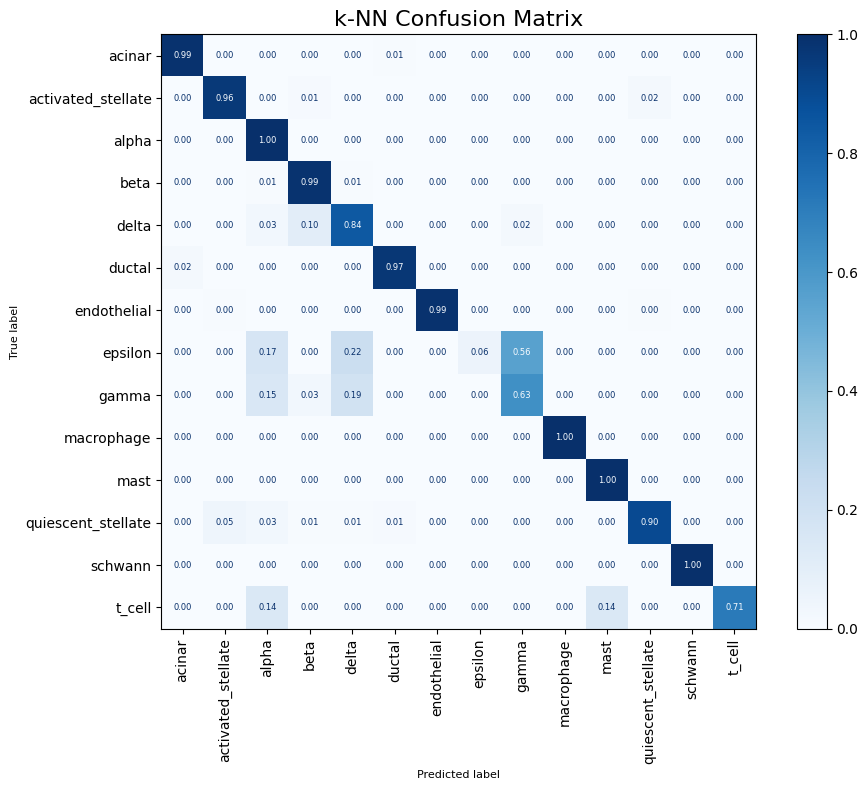

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

# Pancreas Mouse annotation

## Prepare the dataset

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/annotation/pancreas/mouse

In [ ]:
mouse_data_path = os.path.join(data_dir, "GP_datasets/Pancreas/Baron_Pancreas_Combined_Human_Mouse.h5ad")
adata = sc.read_h5ad(mouse_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'

In [ ]:
adata.obs['species'].unique()

['mouse', 'human']
Categories (2, object): ['human', 'mouse']

In [ ]:
adata=adata[adata.obs["species"]=='mouse'].copy()

In [ ]:
adata

AnnData object with n_obs × n_vars = 1868 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'

In [ ]:
adata.obs['species'].unique()

['mouse']
Categories (1, object): ['mouse']

In [ ]:
adata.var.index

Index(['A1CF', 'A4GALT', 'AAAS', 'AACS', 'AADAC', 'AAED1', 'AAGAB', 'AAK1',
       'AAMDC', 'AAMP',
       ...
       'SPRYD3', 'SPRYD4', 'SPRYD7', 'SPSB1', 'SPSB2', 'SPSB3', 'SPSB4',
       'SPTAN1', 'SPTB', 'SPTBN1'],
      dtype='object', length=10335)

In [ ]:

mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='mouse')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")
print(adata.var.head())



INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-10335 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped: 9932 / 10335
                ensembl_id
A1CF    ENSMUSG00000052595
A4GALT  ENSMUSG00000047878
AAAS    ENSMUSG00000036678
AACS    ENSMUSG00000029482
AADAC   ENSMUSG00000027761


In [ ]:
adata

AnnData object with n_obs × n_vars = 1868 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'
    var: 'ensembl_id'

In [ ]:
adata.obs['assay'] = 'inDrop'


In [ ]:
adata

AnnData object with n_obs × n_vars = 1868 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.write(os.path.join(data_dir, "pancreas/Mouse.h5ad"))

In [ ]:
data=os.path.join(data_dir, "pancreas/Mouse.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/annotation/pancreas/mouse"
mouse_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/all_embeddings/mus_musculus_gene.h5 "

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 1 \
    --remove-duplicate-genes \
    --pretrained-embedding {mouse_dir} \
    --output-filename transcriptformer_mouse_2_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-24 15:40:36,834 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-24 15:40:37,120 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-24 15:41:21,202 - INFO - Building gene vocabulary
2

In [ ]:
# os.makedirs(embeddings_dir, exist_ok=True)

# cmd = [
#     "transcriptformer", "inference",
#     "--checkpoint-path", model_dir,
#     "--data-file", data,
#     "--output-path", embeddings_dir,
#     "--batch-size", "4",
#     # "--precision", "16-mixed",        # use half precision
#     "--remove-duplicate-genes",
#     "--output-filename", "transcriptformer_mouse_embeddings.h5ad",
# ]

# result = subprocess.run(cmd, text=True, capture_output=True)
# print(result.stdout)
# print(result.stderr)
# print("Return code:", result.returncode)


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|


Predicting: |          | 0/? [00:00<?, ?it/s]
Predicting DataLoader 0: 100%|██████████| 467/467 [05:53<00:00,  1.32it/s]
Inference completed! Saved embeddings to /content/drive/MyDrive/gp/transcriptformer/annotation/pancreas/mouse/transcriptformer_mouse_embeddings.h5ad

Using 16bit Automatic Mixed Precision (AMP)
You are using the plain M

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,'transcriptformer_mouse_2_embeddings.h5ad'))

In [ ]:
adata

AnnData object with n_obs × n_vars = 1868 × 0
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.34849805,  0.1587682 ,  0.3230201 , ...,  0.3321658 ,
         0.40959862,  0.24240391],
       [ 0.10001647, -0.17377093,  0.27153265, ..., -0.7049796 ,
         0.35727856, -0.14855951],
       [ 0.5133991 ,  0.4406143 ,  0.41564748, ...,  0.23951851,
         0.14632557,  0.5800413 ],
       ...,
       [ 0.31346598,  0.11931115,  0.18394938, ...,  0.17336729,
        -0.3089613 ,  0.43708944],
       [ 0.4290781 ,  0.16681343,  0.44460076, ...,  0.36568686,
         0.02894053, -0.29362494],
       [ 0.43310678,  0.13649741,  0.5816694 , ...,  0.05841442,
         0.05451821,  0.08055983]], shape=(1868, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

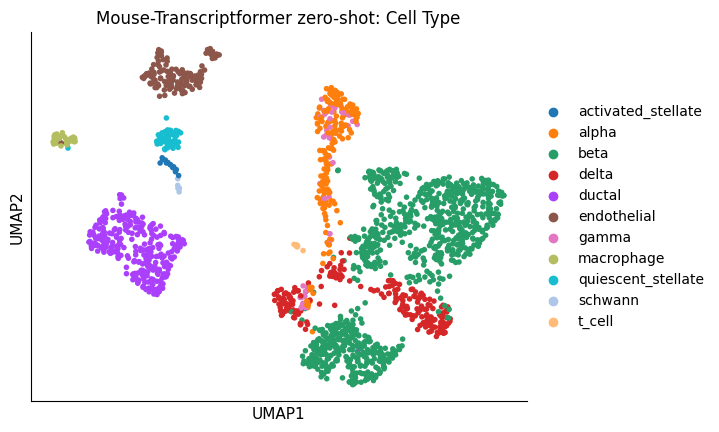

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Mouse-Transcriptformer zero-shot: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

In [ ]:
original.write(os.path.join(embeddings_dir,'transcriptformer_mouse_2_embeddings.h5ad'))

## Annotation

In [ ]:
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_transcriptformer"]
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


=== Logistic Regression ===
Accuracy: 0.978051391862955
                    precision    recall  f1-score   support

activated_stellate       0.93      1.00      0.97        14
             alpha       0.93      0.97      0.95       191
              beta       0.99      0.99      0.99       894
             delta       0.94      0.97      0.96       218
            ductal       1.00      1.00      1.00       275
       endothelial       0.99      0.99      0.99       139
             gamma       0.87      0.66      0.75        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       0.98      0.96      0.97        47
           schwann       1.00      0.83      0.91         6
            t_cell       1.00      1.00      1.00         7

          accuracy                           0.98      1868
         macro avg       0.96      0.94      0.95      1868
      weighted avg       0.98      0.98      0.98      1868



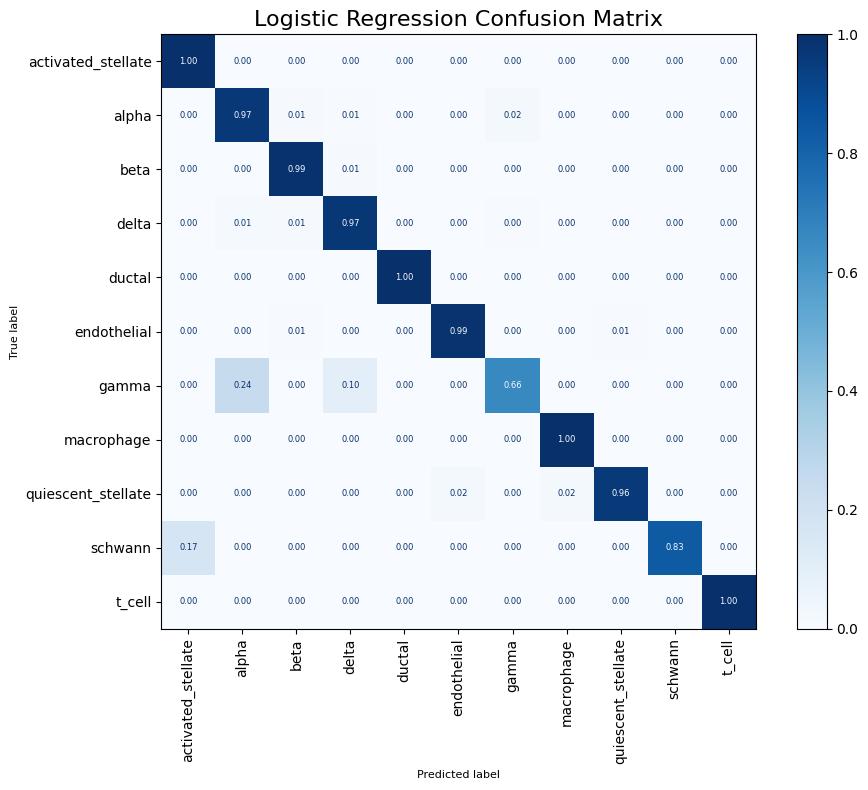


=== k-NN ===
Accuracy: 0.9694860813704497
                    precision    recall  f1-score   support

activated_stellate       0.93      1.00      0.97        14
             alpha       0.89      0.98      0.94       191
              beta       0.99      0.98      0.99       894
             delta       0.91      0.96      0.94       218
            ductal       1.00      1.00      1.00       275
       endothelial       1.00      0.99      1.00       139
             gamma       0.94      0.37      0.53        41
        macrophage       0.95      1.00      0.97        36
quiescent_stellate       1.00      0.98      0.99        47
           schwann       1.00      0.83      0.91         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.97      1868
         macro avg       0.96      0.90      0.92      1868
      weighted avg       0.97      0.97      0.97      1868



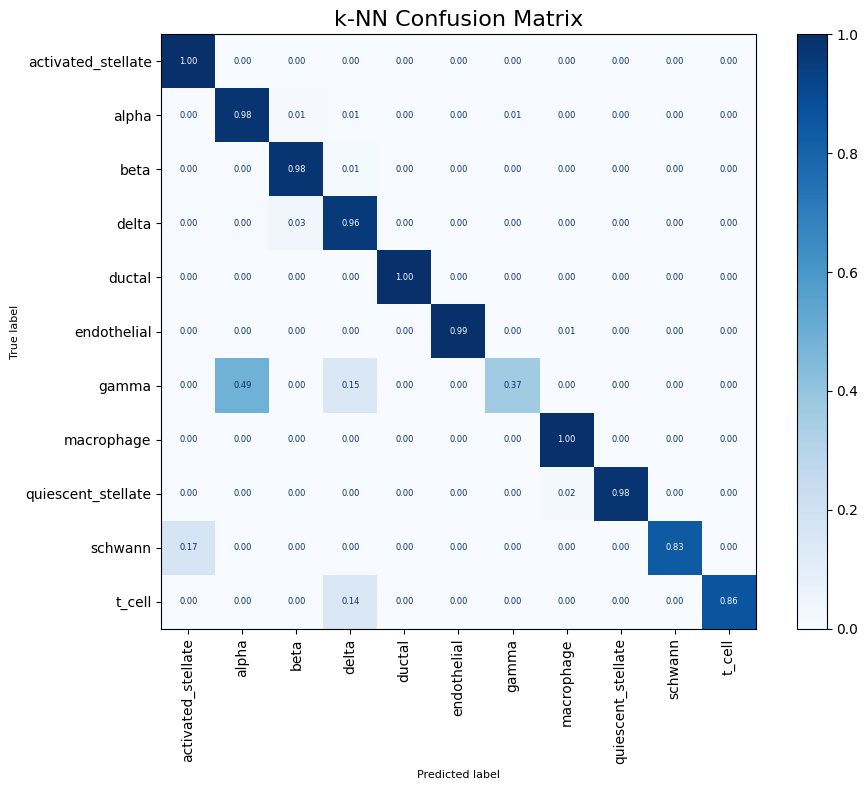

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")